In [1]:
import os
import numpy as np
from PIL import Image
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    TrainingArguments,
    Trainer
)

/home/lidgon02/ViT/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_SIZE = 224
VIT_MODEL  = "google/vit-base-patch16-224-in21k"

Copio dataset a content para agilizar

In [3]:
train_path = "RAF_DB/DATASET/train"
test_path  = "RAF_DB/DATASET/test"

In [4]:
def load_paths(dataset_path):
    paths, labels = [], []
    class_names = sorted(os.listdir(dataset_path))

    for label_idx, label in enumerate(class_names):
        label_path = os.path.join(dataset_path, label)

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            paths.append(img_path)
            labels.append(label_idx)

    return np.array(paths), np.array(labels), class_names

X1, y1, labels = load_paths(train_path)
X2, y2, _      = load_paths(test_path)

id2label = {i: label for i, label in enumerate(labels)}
label2id = {v: k for k, v in id2label.items()}

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X1,
    y1,
    test_size=0.15,
    stratify=y1,
    random_state=16
)

X_test= X2
y_test= y2

Tengo en cuenta el desbalanceo

In [6]:
from sklearn.utils.class_weight import compute_class_weight
classes= np.unique(y_train)
class_weights= compute_class_weight("balanced", classes=classes, y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

Preprocesado

In [7]:
from transformers import AutoImageProcessor
processor = AutoImageProcessor.from_pretrained(VIT_MODEL)

def make_transform(augment=False):
    def transform(example):
        image = Image.open(example["image"]).convert("RGB")
        if augment:
            import torchvision.transforms as T
            aug = T.Compose([
                T.RandomHorizontalFlip(),
                T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
            ])
            image = aug(image)
        inputs = processor(images=image, return_tensors="pt")
        return {"pixel_values": inputs["pixel_values"][0],
                "labels": example["label"]}
    return transform

Construcción Dataset

In [8]:
def to_hf_dataset(paths, labels, augment=False):
    ds = Dataset.from_dict({"image": paths, "label": labels})
    return ds.map(make_transform(augment=augment))

train_ds = to_hf_dataset(X_train, y_train, augment=True)
val_ds   = to_hf_dataset(X_val,   y_val)
test_ds  = to_hf_dataset(X_test,  y_test)

Map:   0%|          | 0/10430 [00:00<?, ? examples/s]

Map: 100%|██████████| 3068/3068 [00:09<00:00, 309.98 examples/s]


Pesos para el trainer

In [9]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Métricas

In [ ]:
def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=1)
    return {
        "accuracy":accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro":f1_score(y_true, y_pred, average="macro"),
    }


Funcion de congelar para el Finetuning de Fase 1. Hago feature extraction, solo entreno el cabezal.

In [11]:
def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable

    print(f"Parámetros totales:      {total:>12,}")
    print(f"Parámetros entrenables:  {trainable:>12,}")
    print(f"Parámetros congelados:   {frozen:>12,}")

In [ ]:
##Función para descongelar ultimos bloques, en total hay 12
def unfreeze_last_blocks(model, n_blocks=4):
    for param in model.parameters():
        param.requires_grad = True

    for name, param in model.named_parameters():
        if "embeddings" in name:
            param.requires_grad = False
        if "encoder.layer" in name:
            block_num = int(name.split("encoder.layer.")[1].split(".")[0])
            if block_num < (12 - n_blocks):
                param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Fase 2 — Trainable params: {trainable:,} / {total:,}")

In [13]:
from transformers import TrainerCallback

class EpochLogCallback(TrainerCallback):
    def on_epoch_begin(self, args, state, control, **kwargs):
        print(f"\nEpoch {int(state.epoch)+1}/{int(args.num_train_epochs)}")
        print("-" * 60)

    def on_evaluate(self, args, state, control, metrics, **kwargs):
        ep  = int(state.epoch)
        acc = metrics.get("eval_accuracy", 0)
        bal = metrics.get("eval_balanced_accuracy", 0)
        f1  = metrics.get("eval_f1_macro", 0)
        loss= metrics.get("eval_loss", 0)
        print(f"val_loss: {loss:.4f} — accuracy: {acc:.4f} — "
              f"balanced_acc: {bal:.4f} — f1_macro: {f1:.4f}")

FASE 1 - Feature Extraction

In [ ]:
model = ViTForImageClassification.from_pretrained(
    VIT_MODEL,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
freeze_backbone(model) ##Congelo todo el backbone

args_fase1 = TrainingArguments(
    output_dir="./vit_fase1",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-3,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro", ##F1 es la que determina el mejor modelo
    greater_is_better=True,
    logging_dir="./logs",
    remove_unused_columns=False,
    dataloader_num_workers=4,
    report_to="none"
)

trainer_fase1 = WeightedTrainer(
    model=model,
    args=args_fase1,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EpochLogCallback()]
)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 217.36it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Parámetros totales:        85,804,039
Parámetros entrenables:         5,383
Parámetros congelados:     85,798,656


In [15]:
trainer_fase1.train()


Epoch 1/10
------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro
1,No log,1.217055,0.619772,0.561815,0.519991
2,1.450488,1.084874,0.661054,0.616922,0.573071
3,1.450488,1.065929,0.677892,0.620604,0.577133
4,1.114103,1.024495,0.689299,0.630015,0.600173
5,1.008446,1.021026,0.682238,0.624814,0.592548
6,1.008446,1.018718,0.667572,0.623765,0.581338
7,0.962546,1.008848,0.686583,0.631535,0.595028
8,0.920072,1.011391,0.691472,0.627736,0.592723
9,0.920072,1.008325,0.686040,0.629323,0.592339
10,0.909796,1.006571,0.688213,0.635909,0.596530


val_loss: 1.2171 — accuracy: 0.6198 — balanced_acc: 0.5618 — f1_macro: 0.5200


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.92s/it]



Epoch 2/10
------------------------------------------------------------
val_loss: 1.0849 — accuracy: 0.6611 — balanced_acc: 0.6169 — f1_macro: 0.5731


...

Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.04s/it]


Epoch 10/10
------------------------------------------------------------


val_loss: 1.0066 — accuracy: 0.6882 — balanced_acc: 0.6359 — f1_macro: 0.5965


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.97s/it]


TrainOutput(global_step=3260, training_loss=1.0481162369616923, metrics={'train_runtime': 2683.5508, 'train_samples_per_second': 38.866, 'train_steps_per_second': 1.215, 'total_flos': 8.082776717426074e+18, 'train_loss': 1.0481162369616923, 'epoch': 10.0})

In [16]:
trainer_fase1.save_model("guardados/vit_fase1_2")

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.50s/it]


Fase 2 - Fine Tuning. Descongelo ultimos bloques -- El dataset es muy pequeño asique esta parte quiza se quite.

In [23]:
model = ViTForImageClassification.from_pretrained("guardados/vit_fase1_2",
                                                   ignore_mismatched_sizes=True)
unfreeze_last_blocks(model, n_blocks=2) ## Descongela 2

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 5635.31it/s]

Fase 2 — Trainable params: 14,182,663 / 85,804,039


In [24]:
args_fase2 = TrainingArguments(
    output_dir="./vit_fase2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=15,        
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro", 
    greater_is_better=True,                 
    logging_dir="./logs",
    remove_unused_columns=False,
    report_to="none"
)

trainer_fase2 = WeightedTrainer(
    model=model,
    args=args_fase2,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
trainer_fase2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro
1,0.952569,1.008176,0.684954,0.629255,0.601281
2,0.930111,0.976045,0.714286,0.647636,0.625382
3,0.860573,0.956066,0.721347,0.658063,0.633453
4,0.762597,0.948177,0.722433,0.653438,0.635176
5,0.682467,0.938229,0.726779,0.658581,0.638914
6,0.667714,0.929888,0.724606,0.667107,0.642705
7,0.581542,0.930660,0.734383,0.666867,0.650605
8,0.525623,0.935164,0.734383,0.661862,0.645507
9,0.512061,0.936018,0.737643,0.667082,0.652125
10,0.466386,0.940866,0.739815,0.664842,0.651880


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.45it/s]


TrainOutput(global_step=9780, training_loss=0.5947996798712295, metrics={'train_runtime': 12960.5634, 'train_samples_per_second': 12.071, 'train_steps_per_second': 0.755, 'total_flos': 1.212416507613911e+19, 'train_loss': 0.5947996798712295, 'epoch': 15.0})

In [26]:
trainer_fase2.save_model("guardados/vit_fase2_final")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.36it/s]


Predicción

In [27]:
preds  = trainer_fase2.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)

Resultados

In [ ]:
print("\nAccuracy:",accuracy_score(y_test, y_pred))
print("Balanced Accuracy:",balanced_accuracy_score(y_test, y_pred))
print("Macro F1:",f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, target_names=labels))


Accuracy: 0.7441329856584094
Balanced Accuracy: 0.661216871153007
Macro F1: 0.6538064877905032
              precision    recall  f1-score   support

       anger       0.58      0.62      0.60       162
     disgust       0.36      0.44      0.40       160
        fear       0.57      0.55      0.56        74
       happy       0.90      0.84      0.87      1185
     neutral       0.72      0.74      0.73       680
         sad       0.68      0.67      0.67       478
    surprise       0.74      0.76      0.75       329

    accuracy                           0.74      3068
   macro avg       0.65      0.66      0.65      3068
weighted avg       0.75      0.74      0.75      3068



In [31]:
import time
import seaborn as sns
import matplotlib.pyplot as plt

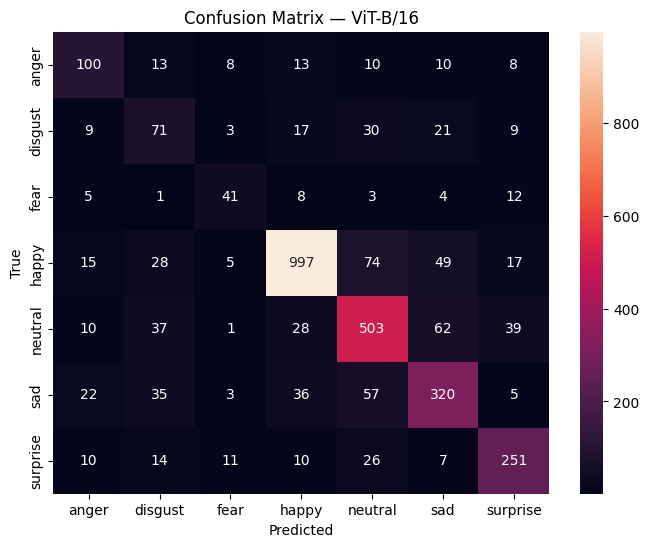

In [32]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — ViT-B/16")
plt.show()
